In [2]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13)]
Creating custom binned grid with 10000 points from 0.7 to 1.7 µm
Binned bin edges shape: 10001
Binned wavelengths shape: 10000

Creating BT-Settl 3D interpolation grid with custom binning...

Wavelength range: 0.700 - 1.700 µm
Number of wavelength points: 10000

Grid creation complete!


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/160 [00:00<?, ?it/s]

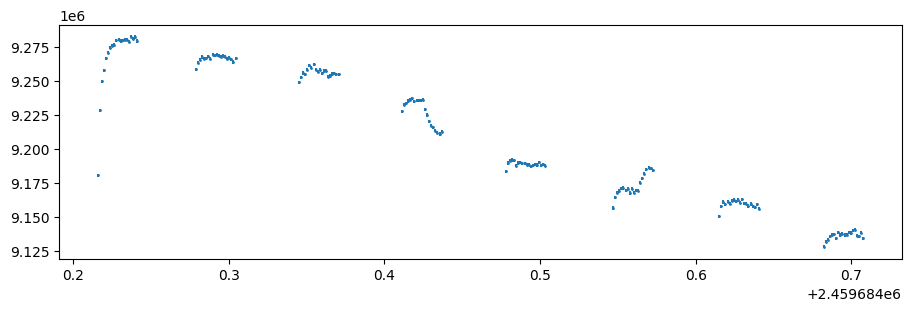

<Figure size 640x480 with 0 Axes>

In [3]:
visit = 'S22'
orbits_to_exclude = np.array([0,1,2,7])

speclc_bin_edges = ([
    0.799213,
    0.807118,
    0.815023,
    0.822928,
    0.878263,
    0.891438,
    0.898026,
    0.917788,
    0.925581,
    0.940567,
    0.948160,
    0.970939,
    0.978532,
    0.986125,
    1.012701,
    1.021560,
    1.039277,
    1.046870,
    1.054463,
    1.062056,
    1.068805,
    1.102552,
    1.109301,
    1.116051,
    1.1304
    ])*u.micron

speclc_err_factor = 10**np.array([
    0.00,
    0.00,
    0.00,
    0.12,
    0.00,
    0.00,
    0.11,
    0.00,
    0.00,
    0.00,
    0.06,
    0.06,
    0.00,
    0.09,
    0.08,
    0.00,
    0.00,
    0.00,
    0.08,
    0.00,
    0.10,
    0.00,
    0.00,
    0.10])

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
_rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
rainbow = _rainbow

speclc_rainbow = rainbow.bin(wavelength_edges = speclc_bin_edges)
for i in range(len(speclc_rainbow.wavelength)):
    speclc_rainbow.uncertainty[i,:] = speclc_rainbow.uncertainty[i,:] * speclc_err_factor[i]

# Check a light curve to verify the spots are getting trimmed
plt.figure(figsize=(9,3))
plt.errorbar(speclc_rainbow.time,speclc_rainbow.flux[10,:],speclc_rainbow.uncertainty[10,:],
            fmt='o',ms=1)
plt.show()
plt.clf()

Median relative photon uncertainty at 0.8032 micron = 374ppm
Median relative photon uncertainty at 0.8111 micron = 348ppm
Median relative photon uncertainty at 0.8190 micron = 329ppm
Median relative photon uncertainty at 0.8506 micron = 135ppm
Median relative photon uncertainty at 0.8849 micron = 177ppm
Median relative photon uncertainty at 0.8947 micron = 241ppm
Median relative photon uncertainty at 0.9079 micron = 172ppm
Median relative photon uncertainty at 0.9217 micron = 202ppm
Median relative photon uncertainty at 0.9331 micron = 142ppm
Median relative photon uncertainty at 0.9444 micron = 195ppm
Median relative photon uncertainty at 0.9595 micron = 125ppm
Median relative photon uncertainty at 0.9747 micron = 213ppm
Median relative photon uncertainty at 0.9823 micron = 183ppm
Median relative photon uncertainty at 0.9994 micron = 119ppm
Median relative photon uncertainty at 1.0171 micron = 198ppm
Median relative photon uncertainty at 1.0304 micron = 114ppm
Median relative photon u

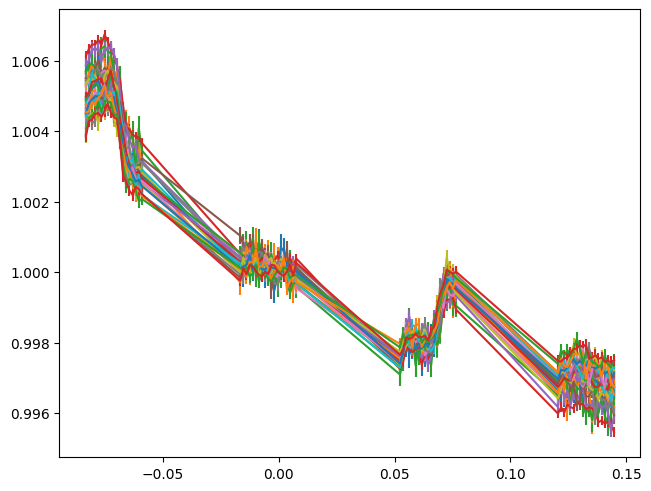

In [4]:
data_wavelengths = speclc_rainbow.wavelength.value
img_date = speclc_rainbow.time.value
data_flux = speclc_rainbow.flux.value
relative_err = speclc_rainbow.uncertainty.value/data_flux
time_from_T0 = img_date - predicted_T0
for i in range(len(data_wavelengths)):
    print(f'Median relative photon uncertainty at {data_wavelengths[i]:.4f} micron = {int(np.nanmedian(relative_err[i,:])*1e6)}ppm')

_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=data_wavelengths)['y'] * u.cm**2 / u.erg

for i,date in enumerate(img_date):
    e_per_s = data_flux[:,i] / exptime
    e_per_s_per_angstrom = e_per_s / binwidth
    calibrated_flux = (e_per_s_per_angstrom.flatten() / binned_filter_response)
    data_flux[:,i] = calibrated_flux.value

# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[:, first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[:, orbit == orbit_to_exclude] = np.nan
    relative_err[:, orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

# Convert all arrays to JAX arrays
data_flux = jnp.array( data_flux[:,~np.isnan(time_from_T0)] )
_relative_err = jnp.array(relative_err[:,~np.isnan(time_from_T0)] )
img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )
ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )

mean_per_wavelength = jnp.mean(data_flux, axis=1, keepdims=True)
normalized_data_flux = data_flux / mean_per_wavelength
relative_err = _relative_err * normalized_data_flux

planet_parameters = dict(
    inclination = np.radians(89.5),
    a = 19.2,
    rp = 0.042,
    period = 8.46,
    t0 = 0,
    ecc = 0.0,
    u1 = 0.25,
    u2 = 0.15)

# Corrected latitude generation - choose distribution for each spot
# choice_indices = np.random.choice([0, 1], size=800)
# dist1 = np.random.beta(2, 1, n_spots) * (1.2 - 0.3) + 0.3
# dist2 = np.random.beta(1, 2, n_spots) * (3.0 - 2.0) + 2.0
# initial_lats = jnp.array(np.where(choice_indices == 0, dist1, dist2))

for i in range(len(data_wavelengths)):
    plt.errorbar(time_from_T0, normalized_data_flux[i,:], relative_err[i,:])

In [5]:
def read_spots_file_to_jax(filename):
    """
    Read spot coordinates from a file and return as JAX arrays.
    
    Parameters:
    - filename: input filename
    
    Returns:
    - latitudes, longitudes as JAX arrays
    - metadata dictionary
    """
    latitudes = []
    longitudes = []
    
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            
            if not line or line.startswith('#'):
                if line.startswith('#') and ':' in line:
                    key_value = line[1:].split(':', 1)
                    if len(key_value) == 2:
                        key = key_value[0].strip()
                        value = key_value[1].strip()
                continue
            
            parts = line.split()
            if len(parts) >= 2:
                try:
                    lat = float(parts[0])
                    lon = float(parts[1])
                    latitudes.append(lat)
                    longitudes.append(lon)
                except ValueError:
                    continue
    
    # Convert to JAX arrays
    latitudes_jax = jnp.array(latitudes)
    longitudes_jax = jnp.array(longitudes)
    
    return latitudes_jax, longitudes_jax

spot_latitudes, spot_longitudes = read_spots_file_to_jax('band_spots.txt')
n_spots = spot_latitudes.size

In [6]:
default_params={

    # Ramp Model Parameters
    'r_1': 3.88,
    'r_2': -4.976,
    'r_3': 0, #0.0135,
    #Breathing params
    'b_1':0.060, # 0.060 +/- ????
    'b_2':-0.247, # -0.247 +/- 0.010
    'b_3':0.343, # 0.343 +/- 0.009
    'b_4':-0.1640, # -0.1640 +/- 0.0006
    'slope':0,
    
    # Planet parameters
    'Mp':20.0,
    'i_planet':89.5,
    'P_orb':8.463,
    't_0':0.00056,
    'rp_rstar': 0.04874,
    'a_rstar': 19.2,
    'ecc': 0.0,
    'u_1':0.35,
    'u1_slope':0,
    'u1_intercept':0,
    'u_2':0.15,
    'u2_slope':0,
    'u2_intercept':0,
    
    # Stellar parameters
    'log_g':4.5,
    'i_star':89.5,
    'P_rot':4.86,
    'Rs':0.8,
    'Ms':0.6,
    'metallicity':0.0,

    # Spot Parameters
    # 'log_fixedspot_radii':-2.0,
    # 'T_unocculted': 3100,
    'T_phot': 3891,
    'T_occulted': 3020,
    'limb_spot_lon':-1.299,
    'limb_spot_lat':0.8,
    'limb_spot_rad':0.22,
    'chord_spot_lon_1':0.057,
    'chord_spot_lat_1':1.65,
    'chord_spot_rad_1':0.0685,
    'chord_spot_lon_2':0.861,
    'chord_spot_lat_2':1.66,
    'chord_spot_rad_2':0.055,

    # Model meta-parameters
    'beta':0.105,

}

In [ ]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = default_params['r_1']
    params['r_2'] = default_params['r_2']
    params['r_3'] = default_params['r_3']

    # Instrument Parameters
    params['b_1'] = default_params['b_1']
    params['b_2'] = default_params['b_2']
    params['b_3'] = default_params['b_3']
    params['b_4'] = default_params['b_4']

    # Baseline Parameters
        
    params['limb_spot_lon'] = numpyro.sample('limb_spot_lon', dist.Uniform(-1.35, -1.3))
    params['limb_spot_lat'] = 0.8 #numpyro.sample('limb_spot_lat', dist.Uniform(0.5, 1.4))
    params['limb_spot_rad'] = numpyro.sample('limb_spot_rad', dist.Uniform(0.2, 0.5))
    
    params['chord_spot_lon_1'] = 0.057#numpyro.sample('chord_spot_lon_1', dist.Uniform(0.03, 0.1))
    params['chord_spot_lat_1'] = numpyro.sample('chord_spot_lat_1', dist.Uniform(1.52, 1.6))
    params['chord_spot_rad_1'] = numpyro.sample('chord_spot_rad_1', dist.Uniform(0.12, 0.22))

    params['chord_spot_lon_2'] = 0.861#numpyro.sample('chord_spot_lon_2', dist.Uniform(0.84,0.88))
    params['chord_spot_lat_2'] = numpyro.sample('chord_spot_lat_2', dist.Uniform(1.745, 1.82))
    params['chord_spot_rad_2'] = numpyro.sample('chord_spot_rad_2', dist.Uniform(0.03, 0.1))

    # Planet Parameters
    params['rp_rstar'] = numpyro.sample('rp_rstar', dist.Uniform(0.045, 0.049),sample_shape=data_wavelengths.shape)
    params['t_0'] = 0.00056 #numpyro.sample('t_0', dist.Uniform(0.00032, 0.00072))
    params['a_rstar'] = 19.20
    
    u1_slope = numpyro.sample('u1_slope', dist.Uniform(0,0.6))
    u1_intercept = numpyro.sample('u1_intercept', dist.Uniform(0.1,0.4))
    params['u_1'] = numpyro.deterministic('u_1', (u1_slope*(data_wavelengths-data_wavelengths[0]) + u1_intercept) )

    u2_slope = numpyro.sample('u2_slope', dist.Uniform(-0.5,0.55))
    u2_intercept = numpyro.sample('u2_intercept', dist.Uniform(0.1,0.4))
    params['u_2'] = numpyro.deterministic('u_2', (u2_slope*(data_wavelengths-data_wavelengths[0]) + u2_intercept) )
    
    # Stellar Parameters
    params['T_phot'] = numpyro.sample('T_phot', dist.TruncatedNormal(loc=3891, scale=37,low=3650,high=4200))
    # delta_T = numpyro.sample('delta_T', dist.Uniform(-1200, 0))
    params['T_occulted'] = numpyro.sample('T_occulted', dist.TruncatedNormal(loc=3020, scale=69,low=2600,high=3600))
    # params['T_unocculted'] = numpyro.sample('T_unocculted', dist.Uniform(2800, 3600))
    # params['log_fixedspot_radii'] = numpyro.sample('log_fixedspot_radii', dist.Uniform(-3.5, -1))
    
    err_inflation = numpyro.sample('beta', dist.Uniform(1.0, 1.5))

    @jit
    def spectroscopic_transit(params,**kwargs):

        # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        _systematics = (breathing * ramp)
        systematics = _systematics/jnp.mean(_systematics)
        sys_2d = systematics[jnp.newaxis, :]
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = jnp.radians(default_params['i_planet']),
            a = jnp.asarray(params['a_rstar'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rstar'], dtype=jnp.float64),
            period = default_params['P_orb'],
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = default_params['ecc'],
            u1 = jnp.asarray(params['u_1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u_2'], dtype=jnp.float64)
        )
        
        # Get spectra for the model temps
        Cool_occulted, Phot = [
            get_BTSettl_spectrum_jax(T=Temp,metallicity=0,data_wave = data_wavelengths)
            for Temp in [jnp.asarray(params['T_occulted'], dtype=jnp.float64),
                        # jnp.asarray(params['T_unocculted'], dtype=jnp.float64),
                        jnp.asarray(params['T_phot'], dtype=jnp.float64)] ]
        
        # Update stellar parameters
        active_star = ActiveStar(
            times = time_from_T0,
            inclination=jnp.radians(default_params['i_star']),
            T_eff=jnp.asarray(params['T_phot'], dtype=jnp.float64),
            wavelength=Phot[0]*1e-6, # convert from micron to m
            phot=Phot[1],
            P_rot=default_params['P_rot']
        )
        
        active_star.spectrum = jnp.concatenate([
            jnp.vstack([Cool_occulted[1],Cool_occulted[1],Cool_occulted[1]]),
            # jnp.vstack([Cool_unocculted[1]]*n_spots)
        ])
        active_star.temperature = jnp.concatenate([
            jnp.array([params['T_occulted'], params['T_occulted'], params['T_occulted']]),
            # jnp.array([params['T_unocculted'] * n_spots])
        ])
        active_star.rad = jnp.concatenate([
            jnp.array([params['chord_spot_rad_1'],params['chord_spot_rad_2'],params['limb_spot_rad']]),
            # jnp.array([10**(jnp.array(params['log_fixedspot_radii']))] * n_spots)
        ])
        active_star.lon = jnp.concatenate([
            jnp.array([params['chord_spot_lon_1'],params['chord_spot_lon_2'],params['limb_spot_lon']]),
            # spot_longitudes
        ])
        active_star.lat = jnp.concatenate([
            jnp.array([params['chord_spot_lat_1'],params['chord_spot_lat_2'],params['limb_spot_lat']]),
            # spot_latitudes
        ])
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T * sys_2d
        mean_per_wavelength = jnp.mean(lc_model, axis=1, keepdims=True)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        'Obs', dist.Normal(
            loc=spectroscopic_transit(params), 
            scale=relative_err*err_inflation,
        ), obs=normalized_data_flux
    )

In [8]:
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

def plot_results(parameter_dict,
                 samples=None,
                 figlabel='missinglabel'):
    """
    Plot multi-wavelength transit light curves after removing systematics
    and stellar rotation. Shows fully detrended (transit-only) light curves
    and residuals, both vertically offset for clarity.

    Parameters
    ----------
    parameter_dict : dict
        Parameter values (MAP or single draw). Must include:
        r_1..r_3, b_1..b_4,
        chord_spot_lon/lat/rad (1,2), limb_spot_lon/lat/rad,
        T_phot, T_occulted, rp_rstar, t_0,
        u1_slope, u1_intercept, u2_slope, u2_intercept.
    samples : optional, not used
    figlabel : str
        Suffix for the saved figure filename.
    """
    params = parameter_dict

    # ---------- 1. Systematics (achromatic) ----------
    ramp = ramp_model_jax(phase=ramp_phase,
                          r1=params.get('r_1', default_params['r_1']),
                          r2=params.get('r_2', default_params['r_2']),
                          r3=params.get('r_3', default_params['r_3']))
    breathing = breathing_model_jax(phase=breathing_phase,
                                    b1=params.get('b_1', default_params['b_1']),
                                    b2=params.get('b_2', default_params['b_2']),
                                    b3=params.get('b_3', default_params['b_3']),
                                    b4=params.get('b_4', default_params['b_4']))
    _systematics = breathing * ramp
    systematics = _systematics / jnp.mean(_systematics)          # mean = 1
    sys_2d = systematics[jnp.newaxis, :]                        # (1, n_times)

    # ---------- 2. Limb-darkening ----------
    if 'u1_slope' in params and 'u1_intercept' in params:
        u1 = params['u1_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u1_intercept']
        u2 = params['u2_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u2_intercept']
    else:
        u1 = params.get('u_1', default_params['u_1'])
        u2 = params.get('u_2', default_params['u_2'])

    # ---------- 3. Planet parameters (with and without planet) ----------
    rp = np.asarray(params.get('rp_rstar', default_params['rp_rstar']))
    planet_parameters = {
        'inclination': jnp.radians(default_params['i_planet']),
        'a': jnp.asarray(params.get('a_rstar', default_params['a_rstar']), dtype=jnp.float64),
        'rp': jnp.asarray(rp, dtype=jnp.float64),
        'period': jnp.asarray(default_params['P_orb'], dtype=jnp.float64),
        't0': jnp.asarray(params.get('t_0', default_params['t_0']), dtype=jnp.float64),
        'ecc': jnp.asarray(default_params['ecc'], dtype=jnp.float64),
        'u1': jnp.asarray(u1, dtype=jnp.float64),
        'u2': jnp.asarray(u2, dtype=jnp.float64),
    }
    no_planet_params = planet_parameters.copy()
    no_planet_params['rp'] = 0.0   # no planet, only rotation

    # ---------- 4. Spectra and active star ----------
    T_occulted = params.get('T_occulted', default_params['T_occulted'])
    T_phot = params.get('T_phot', default_params['T_phot'])

    Cool_occulted, Phot = [
        get_BTSettl_spectrum_jax(T=jnp.asarray(Temp, dtype=jnp.float64),metallicity=0,
                                        data_wave=data_wavelengths)
        for Temp in [T_occulted, T_phot]
    ]

    active_star = ActiveStar(
        times=time_from_T0,
        inclination=jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(T_phot, dtype=jnp.float64),
        wavelength=Phot[0] * 1e-6,      # µm → m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )

    # Three spots (order: limb, chord1, chord2)
    active_star.spectrum = jnp.vstack([Cool_occulted[1]] * 3)
    active_star.temperature = jnp.array([T_occulted] * 3)
    active_star.rad = jnp.array([
        params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']),
        params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
        params.get('limb_spot_rad', default_params['limb_spot_rad'])
    ])
    active_star.lon = jnp.array([
        params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']),
        params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
        params.get('limb_spot_lon', default_params['limb_spot_lon'])
    ])
    active_star.lat = jnp.array([
        params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']),
        params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
        params.get('limb_spot_lat', default_params['limb_spot_lat'])
    ])

    # ---------- 5. Compute transit and rotation models ----------
    lc, _, _, _, _ = active_star.transit_model(**planet_parameters)      # (n_times, n_wavelengths)
    lc_no_planet, _, _, _, _ = active_star.transit_model(**no_planet_params)  # same shape

    # Normalize each wavelength separately
    transit_with_rotation = lc.T   # (n_wavelengths, n_times)
    mean_flux = jnp.mean(transit_with_rotation, axis=1, keepdims=True)
    transit_with_rotation = transit_with_rotation / mean_flux

    rotation_model = lc_no_planet.T   # (n_wavelengths, n_times)
    mean_rot = jnp.mean(rotation_model, axis=1, keepdims=True)
    rotation_curve = rotation_model / mean_rot

    # Transit-only model
    model_fully_detrended = transit_with_rotation / rotation_curve

    # Full model with systematics (not used for plotting but kept for return)
    full_model_with_sys = transit_with_rotation * sys_2d
    normalized_model = full_model_with_sys / jnp.mean(full_model_with_sys, axis=1, keepdims=True)

    # Detrended data: remove systematics AND rotation
    data_fully_detrended = normalized_data_flux / (rotation_curve * sys_2d)
    data_fully_detrended /= jnp.mean(data_fully_detrended, axis=1, keepdims=True)

    # Errors: scale by the same detrending factor
    err_detrended = relative_err / (rotation_curve * sys_2d)

    # ---------- 6. Compute vertical offsets for stacking ----------
    # Use a fraction of the standard deviation of the detrended data
    data_std = np.std(data_fully_detrended)
    offset_scale = 1.1 * data_std
    if offset_scale < 1e-6:
        offset_scale = 0.005

    # For residuals, we can use a smaller offset (e.g., half the data offset)
    # or derive from residual scatter; let's use the same offset_scale but
    # scale it by a factor (e.g., 0.5) to keep residuals from overlapping too much.
    res_offset_scale = offset_scale * 0.5
    if res_offset_scale < 1e-6:
        res_offset_scale = 0.002

    wavelengths = np.asarray(data_wavelengths)
    n_wl = len(wavelengths)

    # ---------- 7. Plotting (2 rows: detrended + residuals) ----------
    fig = plt.figure(figsize=(14, 8), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 2.5], height_ratios=[1, 1])

    # --- Left: stellar map (span both rows) ---
    ax_star = fig.add_subplot(gs[:, 0])
    active_star.plot_star(
        t0=params.get('t_0', default_params['t_0']),
        rp=rp,
        a=params.get('a_rstar', default_params['a_rstar']),
        inclination=np.radians(89.5),
        ecc=default_params['ecc'],
        ax=ax_star
    )

    # --- Right top: fully detrended light curves (transit only) ---
    ax_mid = fig.add_subplot(gs[0, 1])
    norm = mcolors.Normalize(vmin=wavelengths.min(), vmax=wavelengths.max())
    cmap = plt.cm.viridis

    for i, wl in enumerate(wavelengths):
        color = cmap(norm(wl))
        offset = i * offset_scale
        # Detrended data
        ax_mid.errorbar(time_from_T0, data_fully_detrended[i, :] + offset,
                        yerr=err_detrended[i, :],
                        fmt='o', ms=2, color=color, alpha=0.6,
                        label=f'{wl:.2f} µm' if i % 2 == 0 else "")
        # Transit-only model
        ax_mid.plot(time_from_T0, model_fully_detrended[i, :] + offset,
                    'k-', lw=1.2, alpha=0.7)

    ax_mid.set_ylabel('Detrended Flux + offset')
    ax_mid.set_title('Transit Only (Systematics & Rotation removed)')
    ax_mid.grid(alpha=0.3)

    # Colourbar (placed on the top right panel)
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_mid, orientation='vertical', pad=0.02)
    cbar.set_label('Wavelength (µm)')

    # --- Right bottom: residuals (vertically offset) ---
    ax_res = fig.add_subplot(gs[1, 1], sharex=ax_mid)
    for i, wl in enumerate(wavelengths):
        color = cmap(norm(wl))
        offset = i * res_offset_scale
        residuals = (data_fully_detrended[i, :] - model_fully_detrended[i, :]) * 1e6   # ppm
        ax_res.errorbar(time_from_T0, residuals + offset,
                        yerr=err_detrended[i, :] * 1e6,
                        fmt='o', ms=2, color=color, alpha=0.6)
        # Add a faint horizontal line at the offset level to guide the eye
        ax_res.axhline(y=0 + offset, color=color, linestyle='--', alpha=0.3, linewidth=0.8)

    # Add a zero line at the bottom (unoffset)
    ax_res.axhline(y=0, color='k', linestyle='-', alpha=0.5)
    ax_res.set_ylabel('Residuals (ppm) + offset')
    ax_res.set_xlabel('Time from T0')
    ax_res.set_title('Residuals (Data – Transit Model)')
    ax_res.grid(alpha=0.3)

    plt.savefig(f'../../figs/{model_designation}_{figlabel}.png', dpi=400)
    plt.show()
    plt.clf()

    return normalized_model, active_star

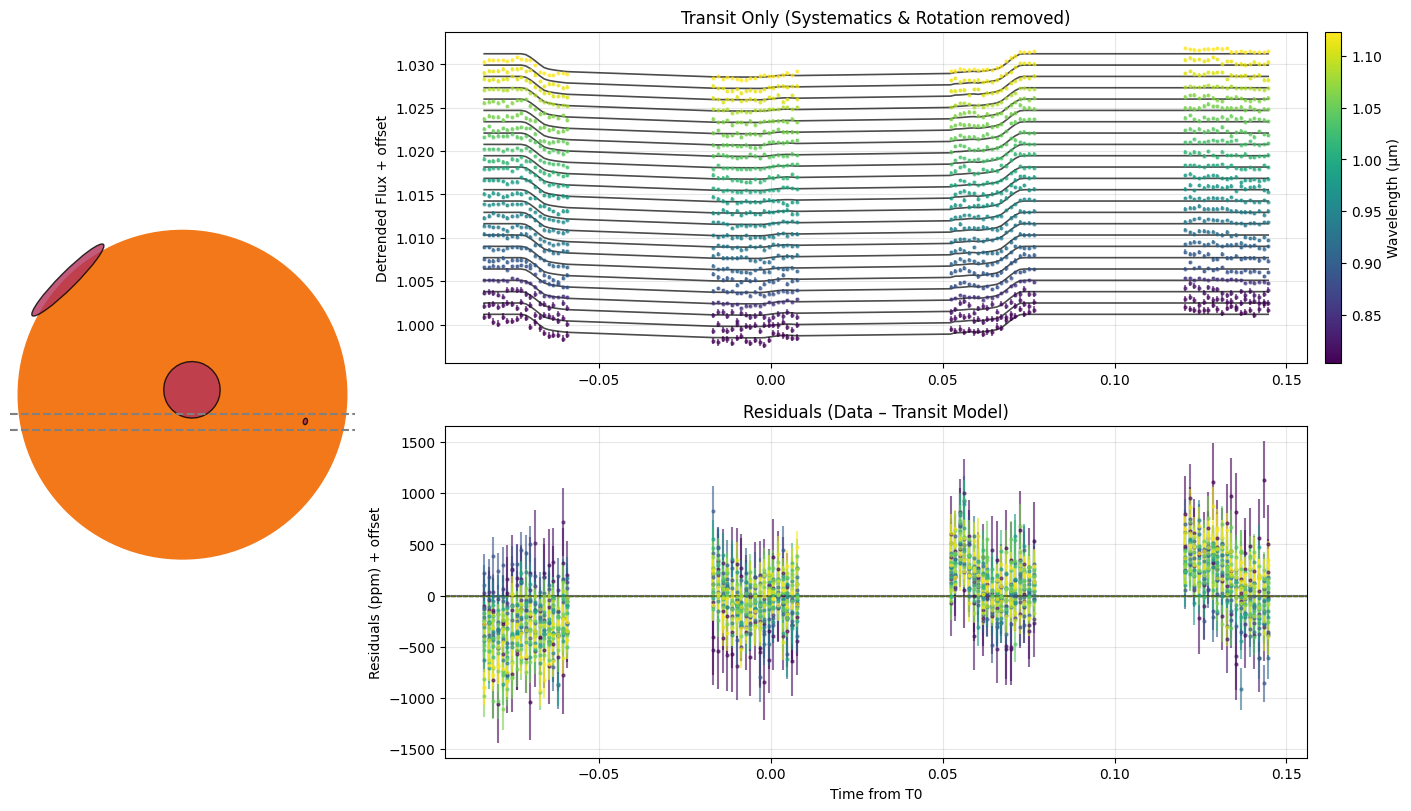

(Array([[1.00597676, 1.00616186, 1.00628583, ..., 0.99606607, 0.9960174 ,
         0.99595105],
        [1.00572912, 1.00591692, 1.00604361, ..., 0.99631463, 0.99626898,
         0.99620563],
        [1.00575129, 1.00593884, 1.00606529, ..., 0.9962924 , 0.99624647,
         0.99618286],
        ...,
        [1.00480836, 1.0050062 , 1.00514302, ..., 0.99723923, 0.99720478,
         0.99715263],
        [1.00481588, 1.00501364, 1.00515037, ..., 0.9972317 , 0.99719716,
         0.99714492],
        [1.00476638, 1.00496468, 1.00510196, ..., 0.99728139, 0.99724745,
         0.99719581]], dtype=float64),
 <fleck.jax.ActiveStar at 0x3532cf3e0>)

<Figure size 640x480 with 0 Axes>

In [9]:
# Define parameters (using slopes/intercepts for LD)
params = {
    # Instrument
    'r_1': 4.172413,
    'r_2': -5.063746,
    'r_3': default_params['r_3'],
    'b_1': default_params['b_1'],
    'b_2': -0.238713,
    'b_3': 0.324703,
    'b_4': -0.151913,
    # Spots
    'limb_spot_lon': -1.337244,
    'limb_spot_lat': 0.8,
    'limb_spot_rad': 0.306391,
    'chord_spot_lon_1': 0.057,
    'chord_spot_lat_1': 1.549748,
    'chord_spot_rad_1': 0.172,
    'chord_spot_lon_2': 0.861,
    'chord_spot_lat_2': 1.74,
    'chord_spot_rad_2': 0.019239,
    # Planet
    'rp_rstar': np.array([0.047190] * len(data_wavelengths)),
    't_0': 0.000479,
    'a_rstar': 19.20,
    # Limb darkening
    'u1_slope': 0.001,
    'u1_intercept': 0.339359,
    'u2_slope': -0.002,
    'u2_intercept': 0.260200,
    # Stellar
    'T_phot': 3891,
    'T_occulted': 3020,
}

model_designation = 'plottingtest'
visit = 'MyVisit'

plot_results(parameter_dict=params, figlabel=model_designation)

In [10]:
def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')
    
    # Get samples in chain-major order
    samples_cumulative = self.get_samples()
    print("T_phot mean/median:", jnp.mean(samples_cumulative['T_phot']), jnp.median(samples_cumulative['T_phot']))
    print("T_occulted mean/median:", jnp.mean(samples_cumulative['T_occulted']), jnp.median(samples_cumulative['T_occulted']))
    
    # Create nicely formatted parameter names for titles
    label_map = {
        'r_1': '$r_1$',
        'r_2': '$r_2$', 
        'r_3': '$r_3$',
        'b_1': '$b_1$',
        'b_2': '$b_2$',
        'b_3': '$b_3$',
        'b_4': '$b_4$',
        'a_rstar': '$a/R_*$',
        'rp_rstar': '$R_p/R_*$',
        't_0': '$t_0$',
        'u_1': '$u_1$',
        'u_2': '$u_2$',
        'u1_slope': '$u_1 slope$',
        'u2_slope': '$u_2 slope$',
        'u1_intercept': '$u_1 intercept$',
        'u2_intercept': '$u_2 intercept$',
        'T_phot': '$T_{\\rm phot}$',
        'T_spot': '$T_{\\rm spot}$',
        'T_occulted': '$T_{\\rm occulted}$',
        'T_unocculted': '$T_{\\rm unocculted}$',
        'limb_spot_lon': '$\\theta_{\\rm limb}$',
        'limb_spot_lat': '$\\phi_{\\rm limb}$',
        'limb_spot_rad': '$R_{\\rm limb}$',
        'chord_spot_lon_1': '$\\theta_{\\rm chord,1}$',
        'chord_spot_lat_1': '$\\phi_{\\rm chord,1}$',
        'chord_spot_rad_1': '$R_{\\rm chord,1}$',
        'chord_spot_lon_2': '$\\theta_{\\rm chord,2}$',
        'chord_spot_lat_2': '$\\phi_{\\rm chord,2}$',
        'chord_spot_rad_2': '$R_{\\rm chord,2}$',
        'beta': '$\\beta$'
    }
    
    # EXTRACT MAXIMUM LIKELIHOOD OR CLOSEST-TO-MEDIAN PARAMETERS
    try:
        # Try to get log probability if available
        if hasattr(self, 'get_log_prob'):
            log_prob = self.get_log_prob()
        elif hasattr(self, '_log_prob'):
            log_prob = self._log_prob
        else:
            raise AttributeError("No log probability method found")
            
        # Find max log prob
        if log_prob.ndim > 1:
            flat_log_prob = log_prob.flatten()
            max_idx = jnp.argmax(flat_log_prob)
        else:
            max_idx = jnp.argmax(log_prob)
        
        # Extract ML parameters
        ml_params = {}
        for param_name, param_samples in samples_cumulative.items():
            flattened = param_samples.flatten()
            ml_params[param_name] = float(flattened[max_idx])
        
        print("Maximum likelihood parameters from samples:")
        for param, value in ml_params.items():
            print(f"  {param}: {value:.6f}")
            
    except:
        # Fallback: Find sample closest to median
        print("Using closest-to-median approach for correlated parameters...")
        
        # Compute median for each parameter
        median_params = {}
        for param_name, param_samples in samples_cumulative.items():
            median_params[param_name] = float(jnp.median(param_samples.flatten()))
        
        # Only include sampled parameters (not deterministics or multi-dim)
        # Exclude u_1, u_2 (deterministic arrays) and rp_rstar (multi-dim)
        exclude_from_distance = ['u_1', 'u_2', 'rp_rstar']
        sampled_param_names = [p for p in samples_cumulative.keys() if p not in exclude_from_distance]
        
        # Define n_samples (total number of draws)
        first_param = sampled_param_names[0]
        n_samples = samples_cumulative[first_param].flatten().shape[0]
        
        median_vector = jnp.array([median_params[name] for name in sampled_param_names])
        
        # Build distance only over these parameters
        best_idx = 0
        min_dist = float('inf')
        for idx in range(n_samples):
            sample_vector = jnp.array([samples_cumulative[name].flatten()[idx] for name in sampled_param_names])
            dist = jnp.sum((sample_vector - median_vector)**2)
            if dist < min_dist:
                min_dist = dist
                best_idx = idx
        
        ml_params = {}
        for param_name, param_samples in samples_cumulative.items():
            ml_params[param_name] = float(param_samples.flatten()[best_idx])
        
        print("ML-like parameters (closest to median vector):")
        for param, value in ml_params.items():
            print(f"  {param}: {value:.6f}")

    # ----- Plot results using the extracted parameters -----
    checkpoint_model, checkpoint_star = plot_results(ml_params, figlabel=f'chkpt_{self.checkpoint}')
    
    # Compute median and 1σ uncertainties (16th and 84th percentiles) for each parameter
    titles = {}
    for param_name, param_samples in samples_cumulative.items():
        flattened = param_samples.flatten()
        median = jnp.percentile(flattened, 50)
        lower = jnp.percentile(flattened, 16)
        upper = jnp.percentile(flattened, 84)
        sigma_lower = median - lower
        sigma_upper = upper - median
        formatted_name = label_map.get(param_name, param_name)
        titles[param_name] = f"{formatted_name} = {median:.4f}^{{+{sigma_upper:.4f}}}_{{-{sigma_lower:.4f}}}"
    
    labels = [label_map.get(param, param) for param in samples_cumulative.keys()]
    
    # ----- Corner plot: exclude multi‑dim parameters to avoid huge plots -----
    exclude_corner = ['rp_rstar', 'u_1', 'u_2']   # also any other arrays
    corner_params = {k: v for k, v in samples_cumulative.items() if k not in exclude_corner}
    # Update titles and labels for corner
    corner_titles = {k: titles[k] for k in corner_params.keys()}
    corner_labels = [label_map.get(k, k) for k in corner_params.keys()]
    
    corner.corner(corner_params, 
                  quantiles=[0.16, 0.50, 0.84],
                  titles=corner_titles,
                  labels=corner_labels,
                  title_kwargs={"fontsize": 11},
                  show_titles=True)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/{visit}_chkpt_{self.checkpoint}_whitelight_corner.png', dpi=400)
    plt.show()
    plt.clf()

    # Save cumulative samples
    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

In [11]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

  0%|          | 0/11 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]

...

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

Corner for checkpoint 0
T_phot mean/median: 3822.8193629884554 3823.6362497407235
T_occulted mean/median: 3219.212067172205 3216.325361053726
Using closest-to-median approach for correlated parameters...
ML-like parameters (closest to median vector):
  T_occulted: 3216.223263
  T_phot: 3823.482877
  beta: 1.337779
  chord_spot_lat_1: 1.581305
  chord_spot_lat_2: 1.758018
  chord_spot_rad_1: 0.139597
  chord_spot_rad_2: 0.050713
  limb_spot_lon: -1.327401
  limb_spot_rad: 0.336544
  rp_rstar: 0.046453
  u1_intercept: 0.256123
  u1_slope: 0.052522
  u2_intercept: 0.205301
  u2_slope: 0.472262
  u_1: 0.402962
  u_2: 0.164660


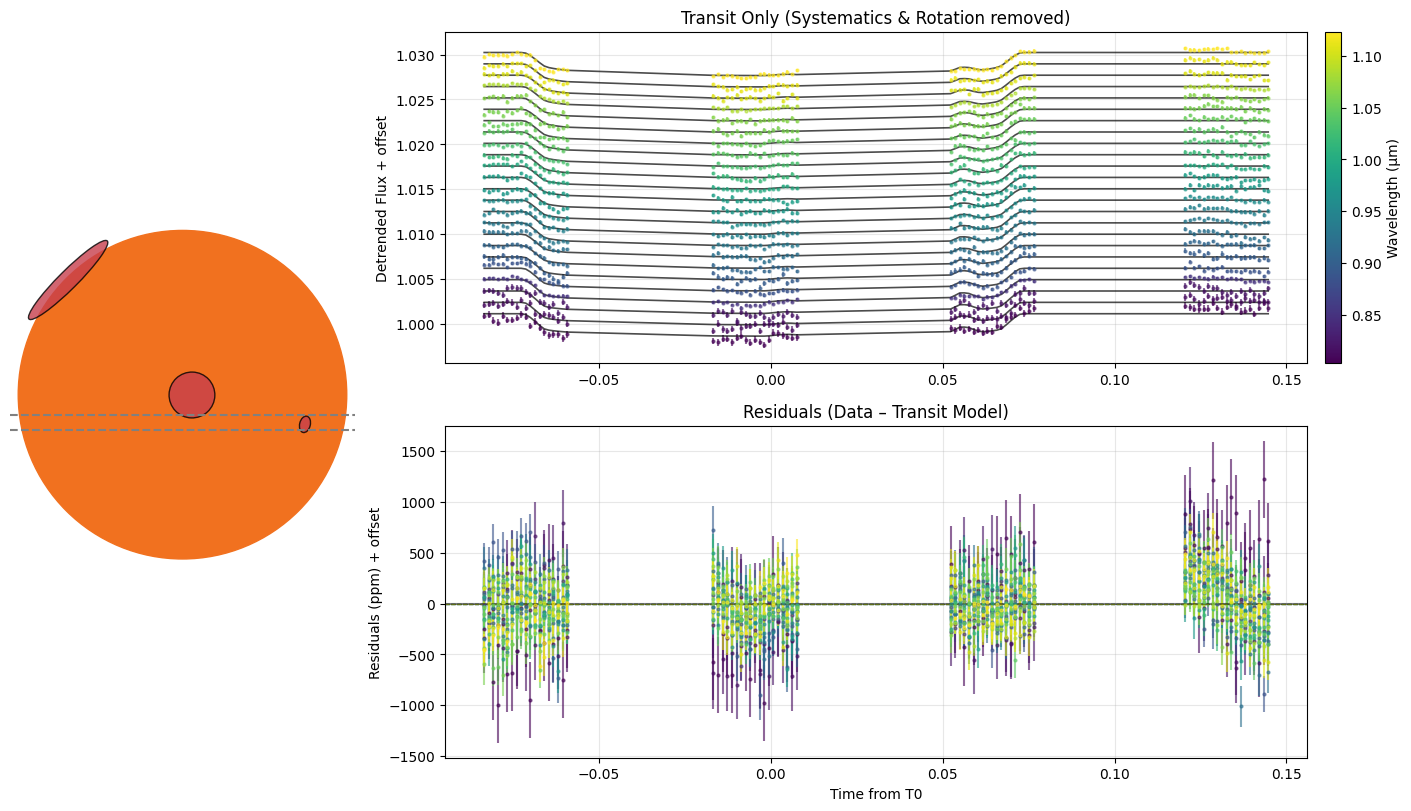

/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


<Figure size 640x480 with 0 Axes>

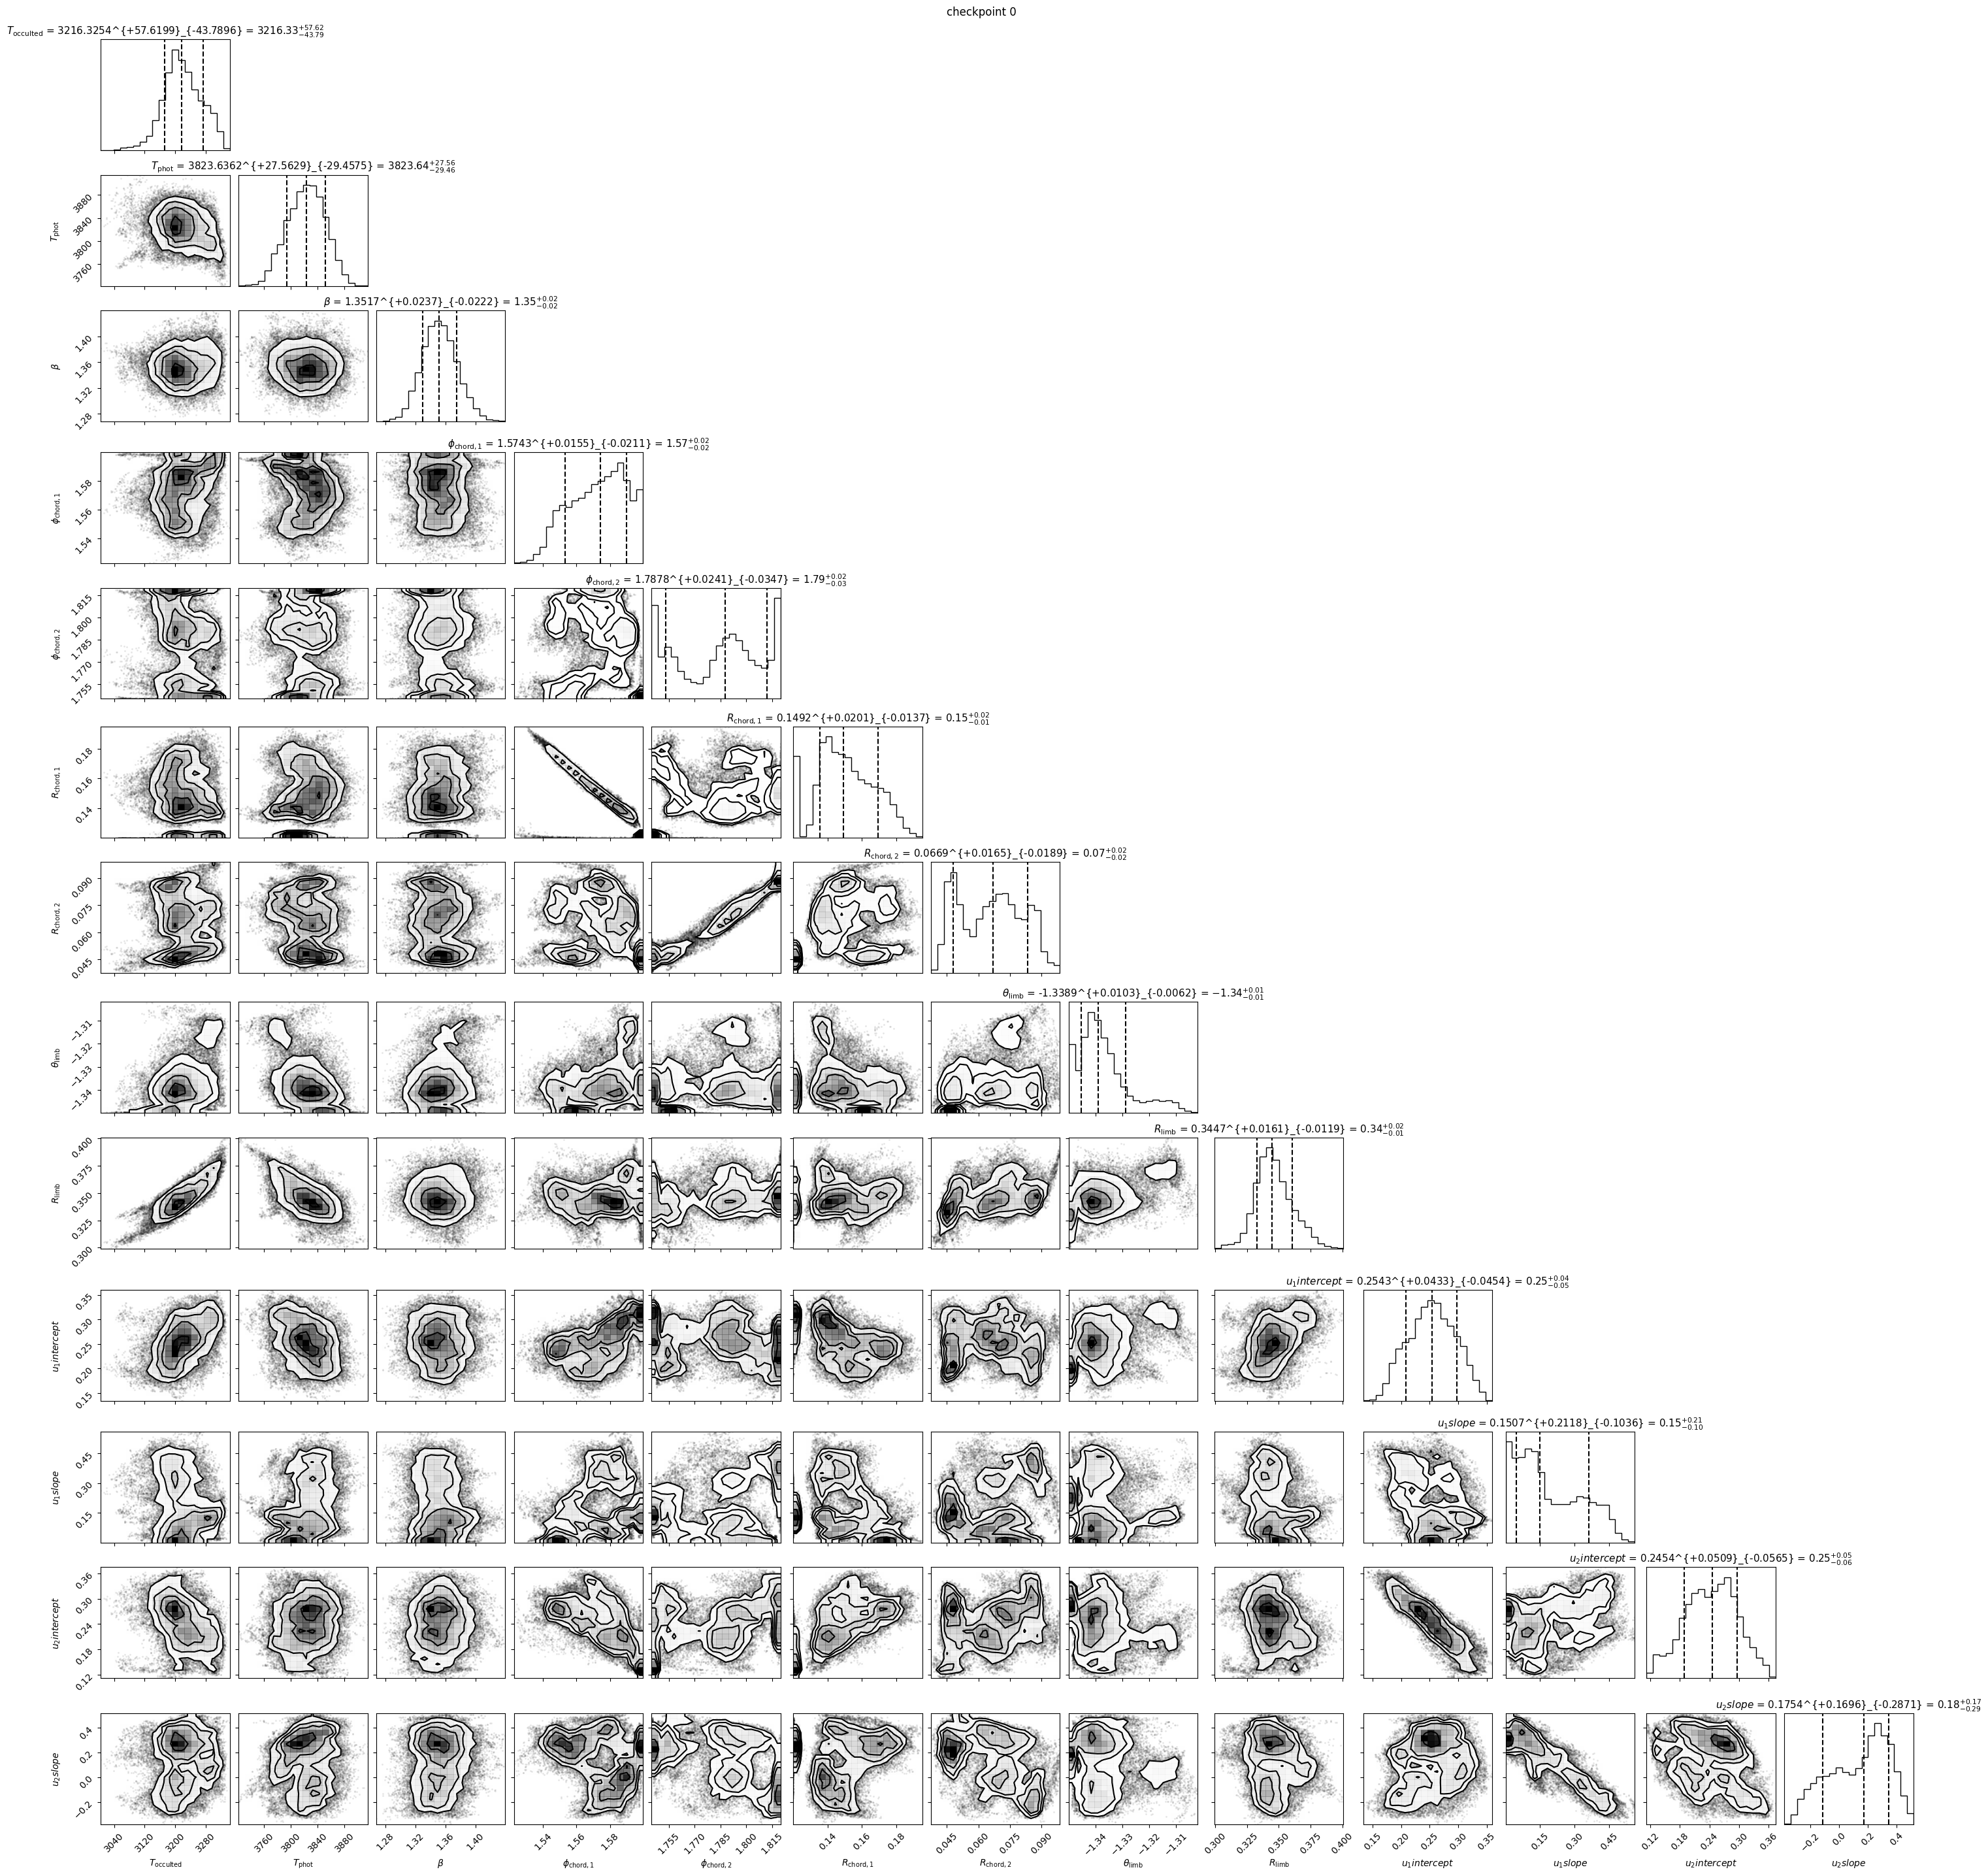

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

...

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

  0%|          | 0/3000 [00:00<?, ?it/s]

In [ ]:
n_warmup = 6_000
n_samples = 30_000
n_chains = 12
n_checks = 10
current_date = datetime.now().strftime("%Y_%m_%d")

model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_{current_date}_specLC'

rng_key = PRNGKey(40)

sampler = NUTS(
    numpyro_model,
    dense_mass=True
    )

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_checks, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()                                                                        

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

median_params = arviz.summary(result,stat_focus='median')
print(median_params)
'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')
'Print the summary'
arviz.summary(result)

'Make a corner plot'
corner.corner(
    result,
)
plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=200)

'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import arviz as az

def calculate_model(parameter_dict, relative_flux, lc_index):
    """
    Compute the transit model for a given wavelength index and return
    normalized model, residuals, detrended model, and detrended data.
    
    Parameters
    ----------
    parameter_dict : dict
        Parameter values (MAP or draw). Must contain all required parameters.
    relative_flux : array
        Observed flux for the specific wavelength (1D, length n_times).
    lc_index : int
        Index of the wavelength in the multi-wavelength array.
    
    Returns
    -------
    normalized_model : array
        Model including systematics, normalized to mean=1.
    residuals : array
        relative_flux - normalized_model.
    de_trended_model : array
        Model with systematics divided out, normalized to mean=1.
    de_trended_data : array
        Data with systematics divided out, normalized to mean=1.
    """
    params = parameter_dict

    # ----- 1. Systematics (achromatic) -----
    ramp = ramp_model_jax(phase=ramp_phase,
                          r1=jnp.asarray(params.get('r_1', default_params['r_1']), dtype=jnp.float64),
                          r2=jnp.asarray(params.get('r_2', default_params['r_2']), dtype=jnp.float64),
                          r3=jnp.asarray(params.get('r_3', default_params['r_3']), dtype=jnp.float64))
    breathing = breathing_model_jax(phase=breathing_phase,
                                    b1=jnp.asarray(params.get('b_1', default_params['b_1']), dtype=jnp.float64),
                                    b2=jnp.asarray(params.get('b_2', default_params['b_2']), dtype=jnp.float64),
                                    b3=jnp.asarray(params.get('b_3', default_params['b_3']), dtype=jnp.float64),
                                    b4=jnp.asarray(params.get('b_4', default_params['b_4']), dtype=jnp.float64))
    _systematics = breathing * ramp
    systematics = _systematics / jnp.mean(_systematics)

    # ----- 2. Limb‑darkening coefficients (per wavelength) -----
    if 'u1_slope' in params and 'u1_intercept' in params:
        u1 = params['u1_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u1_intercept']
        u2 = params['u2_slope'] * (data_wavelengths - data_wavelengths[0]) + params['u2_intercept']
    else:
        # Fallback to direct u_1, u_2 (could be arrays or scalars)
        u1 = params.get('u_1', default_params['u_1'])
        u2 = params.get('u_2', default_params['u_2'])

    # ----- 3. Planet parameters -----
    planet_parameters = {
        'inclination': jnp.radians(default_params['i_planet']),
        'a': jnp.asarray(params.get('a_rstar', default_params['a_rstar']), dtype=jnp.float64),
        'rp': jnp.asarray(params.get('rp_rstar', default_params['rp_rstar']), dtype=jnp.float64),
        'period': jnp.asarray(params.get('P_orb', default_params['P_orb']), dtype=jnp.float64),
        't0': jnp.asarray(params.get('t_0', default_params['t_0']), dtype=jnp.float64),
        'ecc': jnp.asarray(params.get('ecc', default_params['ecc']), dtype=jnp.float64),
        'u1': jnp.asarray(u1, dtype=jnp.float64),
        'u2': jnp.asarray(u2, dtype=jnp.float64),
    }

    # ----- 4. Spectra and active star -----
    T_phot = params.get('T_phot', default_params['T_phot'])
    # Try T_occulted first, fallback to T_spot for backward compatibility
    T_occulted = params.get('T_occulted', params.get('T_spot', default_params.get('T_spot', 3000)))

    Phot = get_BTSettl_spectrum_jax(T=jnp.asarray(T_phot, dtype=jnp.float64),metallicity=0,
                                           data_wave=data_wavelengths)
    Cool = get_BTSettl_spectrum_jax(T=jnp.asarray(T_occulted, dtype=jnp.float64),metallicity=0,
                                           data_wave=data_wavelengths)

    active_star = ActiveStar(
        times=time_from_T0,
        inclination=jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(T_phot, dtype=jnp.float64),
        wavelength=Phot[0] * 1e-6,          # µm → m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )

    # Three spots: limb, chord1, chord2 (order matches the model)
    active_star.spectrum = jnp.vstack([Cool[1]] * 3)
    active_star.temperature = jnp.array([T_occulted] * 3)
    active_star.lon = jnp.array([
        params.get('limb_spot_lon', default_params['limb_spot_lon']),
        params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']),
        params.get('chord_spot_lon_2', default_params['chord_spot_lon_2'])
    ])
    active_star.lat = jnp.array([
        params.get('limb_spot_lat', default_params['limb_spot_lat']),
        params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']),
        params.get('chord_spot_lat_2', default_params['chord_spot_lat_2'])
    ])
    active_star.rad = jnp.array([
        params.get('limb_spot_rad', default_params['limb_spot_rad']),
        params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']),
        params.get('chord_spot_rad_2', default_params['chord_spot_rad_2'])
    ])

    # ----- 5. Transit model -----
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)
    # lc shape: (n_times, n_wavelengths)
    lc_model = lc.T[lc_index] * systematics          # (n_times,)
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength

    residuals = relative_flux - normalized_model
    de_trended_model = normalized_model / systematics
    de_trended_data = relative_flux / systematics

    return (normalized_model, residuals,
            de_trended_model / jnp.mean(de_trended_model),
            de_trended_data / jnp.mean(de_trended_data))


def get_representative_sample_from_dict(posterior_dict_entry, method='median'):
    """
    Extract a single representative sample from an ArviZ posterior dataset.
    The sample chosen is the one closest to the medians of all parameters.

    Parameters
    ----------
    posterior_dict_entry : xarray.Dataset
        The posterior dataset (e.g., `result.posterior`).
    method : str
        Currently only 'median' is supported.

    Returns
    -------
    dict
        Parameter names and their values for the representative sample.
    """
    posterior_dataset = posterior_dict_entry
    medians = posterior_dataset.median()
    param_names = list(posterior_dataset.data_vars)

    all_samples = []
    median_values = []
    for param in param_names:
        samples = posterior_dataset[param].values.flatten()
        all_samples.append(samples)
        median_values.append(float(medians[param]))

    param_matrix = np.column_stack(all_samples)          # (n_samples, n_params)
    median_array = np.array(median_values)               # (n_params,)

    distances = np.linalg.norm(param_matrix - median_array, axis=1)
    closest_idx = np.argmin(distances)

    representative_params = {}
    for i, param in enumerate(param_names):
        representative_params[param] = param_matrix[closest_idx, i]

    return representative_params


def plot_mosaic_lightcurves(data_wavelengths, jax_flux, jax_rel_err, time_from_T0,
                            posterior_samples_dict, model_designation_base,
                            cmap_name='inferno_r', vertical_spacing=0.01):
    """
    Create a stacked mosaic of detrended light curves and residuals for all wavelengths.

    Parameters
    ----------
    data_wavelengths : array
        Wavelength values for each light curve.
    jax_flux : 2D array
        Flux values, shape (n_lc, n_times).
    jax_rel_err : 2D array
        Uncertainties, shape (n_lc, n_times).
    time_from_T0 : array
        Time array.
    posterior_samples_dict : dict
        Dictionary mapping index -> ArviZ posterior dataset.
    model_designation_base : str
        Base name for saving the figure.
    cmap_name : str
        Matplotlib colormap name.
    vertical_spacing : float
        Vertical offset between adjacent light curves.

    Returns
    -------
    fig, (ax_lc, ax_res)
    """
    n_lc = len(data_wavelengths)
    sorted_indices = np.argsort(data_wavelengths)       # shortest to longest

    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i / (n_lc - 1)) for i in range(n_lc)]

    fig, (ax_lc, ax_res) = plt.subplots(1, 2, figsize=(9, 8), sharey=False)
    plt.subplots_adjust(wspace=0.05)

    x_mid = (time_from_T0.min() + time_from_T0.max()) / 2

    for plot_idx, lc_idx in enumerate(sorted_indices):
        relative_flux = jax_flux[lc_idx, :]
        data_unc = jax_rel_err[lc_idx, :]
        wavelength = data_wavelengths[lc_idx]
        color = colors[lc_idx]

        offset = plot_idx * vertical_spacing

        # Get representative sample and compute model
        param_medians = get_representative_sample_from_dict(posterior_samples_dict[lc_idx])
        _, residuals, median_model, detrended_relative_flux = calculate_model(
            param_medians, relative_flux, lc_idx
        )

        # ---- Left panel: light curves ----
        ax_lc.errorbar(time_from_T0, detrended_relative_flux - offset - 0.00025,
                       yerr=data_unc, fmt='o', ms=2,
                       color=color, alpha=0.7, markeredgecolor='k', markeredgewidth=0.5)
        ax_lc.plot(time_from_T0, median_model - offset - 0.00025,
                   '-', color='k', linewidth=1.5, alpha=0.8)

        # Wavelength label
        ax_lc.text(x_mid - 0.07, detrended_relative_flux.mean() - 0.0012 - offset,
                   f'{wavelength:.3f} µm', fontsize=9, color='k',
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='none', edgecolor='none'))

        # Median uncertainty label
        if lc_idx == 0:
            label = r'$\rm \tilde{\sigma}_{obs}$=' + f'{int(np.median(data_unc)*1e6)} ppm'
            xpos = x_mid
        else:
            label = f'{int(np.median(data_unc)*1e6)} ppm'
            xpos = x_mid + 0.0075
        ax_lc.text(xpos, detrended_relative_flux.mean() - 0.0012 - offset,
                   label, fontsize=9, color='k',
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='none', edgecolor='none'))

        # ---- Right panel: residuals ----
        ax_res.errorbar(time_from_T0, residuals - offset,
                        yerr=data_unc, fmt='o', ms=2,
                        color=color, alpha=0.7, markeredgecolor='k', markeredgewidth=0.5)

        rchisquare = jnp.sum((residuals**2) / (data_unc**2)) / (len(data_unc) - 6)
        if lc_idx == 0:
            label = r'$\rm r\chi^2 = $' + f'{rchisquare:.2f}'
            xpos = x_mid
        else:
            label = f'{rchisquare:.2f}'
            xpos = x_mid + 0.0075
        ax_res.text(xpos, residuals.mean() - offset,
                    label, fontsize=9, color='k',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'))

        ax_res.axhline(y=0 - offset, color='k', linestyle='--', alpha=0.5, linewidth=1)

    # Axis limits and labels
    ax_lc.set_xlim(-0.09, 0.09)
    ax_res.set_xlim(-0.09, 0.09)
    ax_lc.set_ylim(0.956, 1.00215)
    ax_res.set_ylim(-0.0448, 0.0014)

    ax_lc.set_ylabel('Relative Flux (offset)', fontsize=12)
    ax_lc.set_xlabel('Time from T0', fontsize=12)

    ax_res.set_ylabel('')                         # hide right ylabel
    ax_res.set_xlabel('Time from T0 (d)', fontsize=12)
    ax_res.set_yticklabels([])
    ax_res.yaxis.set_ticks_position('none')
    ax_res.tick_params(axis='y', which='both', length=0)

    ax_lc.set_title('De-Trended Light Curves')
    ax_res.set_title('Median Fit Residuals')

    fig.tight_layout(pad=1.0)
    plt.subplots_adjust(wspace=0.0)

    plt.savefig(f'../../figs/{model_designation_base}_mosaic.png', dpi=400, bbox_inches='tight')
    plt.show()

    return fig, (ax_lc, ax_res)

In [ ]:
plt.figure()
plt.xlabel('Wavelength (micron)')
plt.ylabel('Transit Depth (Rp/R*)^2')

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22,23]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}_{current_date}_transitonly_fixedr'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]

    result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')

    # Extract posterior samples
    posterior = result.posterior
    
    # Print median and standard deviation for all parameters with high precision
    # print(f"\n=== Results for lc_index {lc_index} ===")
    
    # Calculate median and std for all parameters
    param_medians = posterior.median()
    param_stds = posterior.std()
    
    # Print each parameter with the required precision
    # for var_name in posterior.data_vars:
    median_val = float(param_medians['rp_rstar'].values)
    std_val = float(param_stds['rp_rstar'].values)
    print(f"{data_wavelengths[lc_index]:.5f} {speclc_bin_edges.value[lc_index]:.5f} {speclc_bin_edges.value[lc_index+1]:.5f} {median_val:.5f} {std_val:.6f}")
    rel_err = std_val/median_val
    
    plt.errorbar(data_wavelengths[lc_index], median_val**2, yerr=rel_err * median_val**2,fmt='o',color='k')


plt.savefig(f'../../figs/{model_designation}_transmissionspec.png')

In [ ]:
# Collect all data first to ensure consistent headers
all_data = []

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22,23]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}_{current_date}_transitonly_fixedr'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]

    result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')
    
    # Extract posterior samples
    posterior = result.posterior
    
    # Calculate median and std for all parameters
    param_medians = posterior.median()
    param_stds = posterior.std()
    
    # Store data for this lc_index
    data_entry = {
        'wavelength': data_wavelengths[lc_index],
        'bin_low': speclc_bin_edges.value[lc_index],
        'bin_high': speclc_bin_edges.value[lc_index+1],
        'params': {}
    }
    
    for var_name in posterior.data_vars:
        data_entry['params'][var_name] = {
            'median': float(param_medians[var_name].values),
            'std': float(param_stds[var_name].values)
        }
    
    all_data.append(data_entry)

# Print headers (get param names from first entry)
if all_data:
    param_names = list(all_data[0]['params'].keys())
    
    # Print header
    header = f"{'wavelength':<12} {'bin_low':<12} {'bin_high':<12}"
    for param in param_names:
        header += f" {param}_median {param}_std"
    print(header)
    
    # Print data rows
    for data in all_data:
        row = f"{data['wavelength']:<12.5f} {data['bin_low']:<12.5f} {data['bin_high']:<12.5f}"
        for param in param_names:
            median_val = data['params'][param]['median']
            std_val = data['params'][param]['std']
            row += f" {median_val:.5f} {std_val:.6f}"
        print(row)